In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch.optim.lr_scheduler import StepLR
from neuralop.models import FNO
from neuralop.layers.channel_mlp import ChannelMLP
from neuralop.utils import count_model_params
import sys
import os

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
# Input grid: C 코드와 같은 방식으로 생성
rows = 65
cols = 65
g = 2.0

# C 코드의 x, y: ghost/corner 포함 좌표 (길이 67)
i_x = torch.linspace(0, cols + 1, cols + 2, dtype=torch.float32)
i_y = torch.linspace(0, rows + 1, rows + 2, dtype=torch.float32)

x = 0.5 * (1 - torch.tanh(g * (1.0 - 2.0 * (i_x - 1.0) / (cols - 1))) / np.tanh(g))
y = 0.5 * (1 - torch.tanh(g * (1.0 - 2.0 * (i_y - 1.0) / (rows - 1))) / np.tanh(g))

# C 코드의 xc, yc: cell center 좌표 (길이 66)
xc = 0.5 * (x[:-1] + x[1:])
yc = 0.5 * (y[:-1] + y[1:])

# 모델 입력은 65x65 격자를 쓰도록 cell center 중 앞의 65개 사용
x_model = xc[:cols]
y_model = yc[:rows]
t = torch.linspace(5, 10, 51)

X, Y, T = torch.meshgrid(x_model, y_model, t, indexing='ij')
grid_tensor = torch.stack([X, Y, T], dim=-1)
input_tensor = grid_tensor.unsqueeze(0)

print(f'x shape: {x.shape}, xc shape: {xc.shape}')
print(f'y shape: {y.shape}, yc shape: {yc.shape}')
print(f'model grid shape: {grid_tensor.shape}')

input_tensor_permuted = input_tensor.permute(0, 4, 1, 2, 3).to(DEVICE)
print(f'최종 Input 텐서의 형태 (Shape): {input_tensor_permuted.shape}')

x shape: torch.Size([67]), xc shape: torch.Size([66])
y shape: torch.Size([67]), yc shape: torch.Size([66])
model grid shape: torch.Size([65, 65, 51, 3])
최종 Input 텐서의 형태 (Shape): torch.Size([1, 3, 65, 65, 51])


In [4]:
from scipy.interpolate import RegularGridInterpolator

# initial values
rows, cols = 65, 65

u = np.fromfile('/home/seongwon/cavity/data_re500/u_50000.bin', dtype=np.float64).reshape(rows + 1, cols)
v = np.fromfile('/home/seongwon/cavity/data_re500/v_50000.bin', dtype=np.float64).reshape(rows, cols + 1)
p = np.fromfile('/home/seongwon/cavity/data_re500/p_50000.bin', dtype=np.float64).reshape(rows + 1, cols + 1)


gamma = (x[1:-1] - xc[0:-1])/(xc[1:]-xc[0:-1])
gamma = np.tile(gamma.reshape(-1, 1), (1, cols))
delta = (y[1:-1] - yc[0:-1])/(yc[1:]-yc[0:-1])
delta = np.tile(delta.reshape(-1, 1), (1, rows))
u_new = delta * u[1:, :]+(1 - delta) * u[:-1, :]
v_new = gamma * v[:, 1:]+(1 - gamma) * v[:, :-1]
p_new = 1/4 * (p[:-1, :-1] + p[1:, :-1] + p[:-1, 1:] + p[1:, 1:])


u_tensor = torch.from_numpy(u_new.T).float().to(DEVICE)
v_tensor = torch.from_numpy(v_new.T).float().to(DEVICE)
p_tensor = torch.from_numpy(p_new.T).float().to(DEVICE)

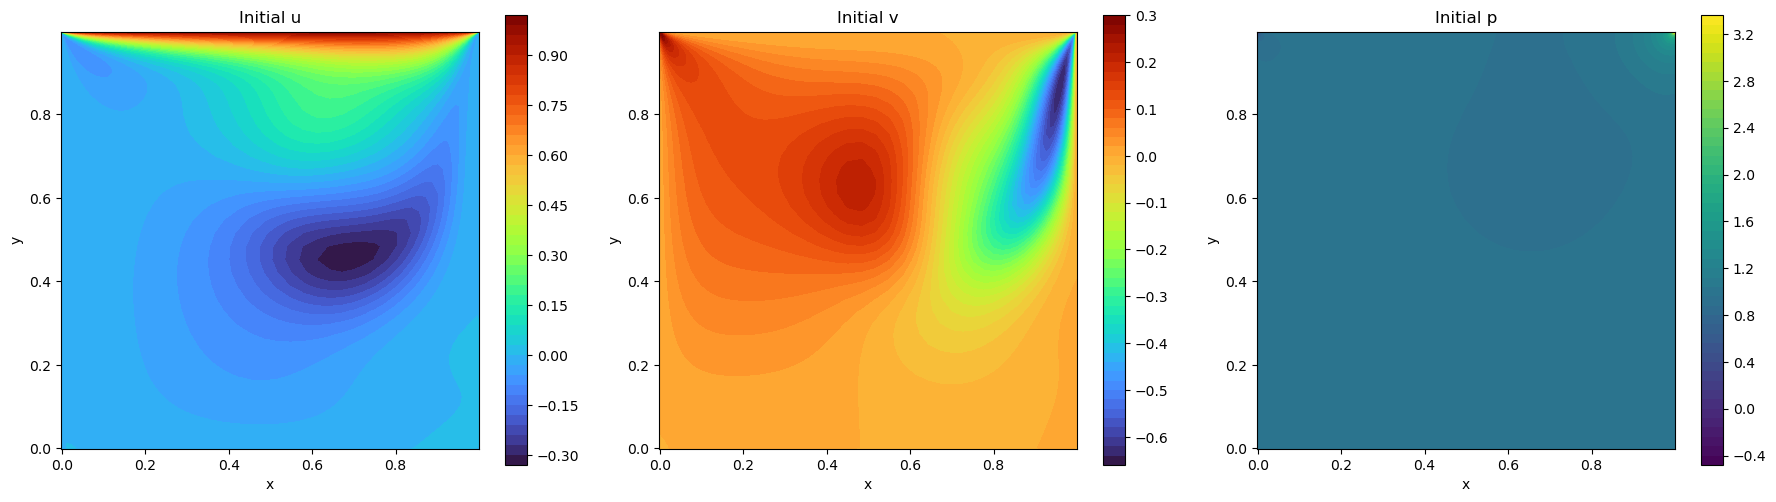

In [7]:
# initial condition 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

x_plot = X[:, :, 0].cpu()
y_plot = Y[:, :, 0].cpu()

im0 = axes[0].contourf(x_plot, y_plot, u_tensor.cpu(), levels=50, cmap='turbo')
axes[0].set_title('Initial u')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
fig.colorbar(im0, ax=axes[0])

im1 = axes[1].contourf(x_plot, y_plot, v_tensor.cpu(), levels=50, cmap='turbo')
axes[1].set_title('Initial v')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
fig.colorbar(im1, ax=axes[1])

im2 = axes[2].contourf(x_plot, y_plot, p_tensor.cpu(), levels=50, cmap='viridis')
axes[2].set_title('Initial p')
axes[2].set_xlabel('x')
axes[2].set_ylabel('y')
fig.colorbar(im2, ax=axes[2])

for ax in axes:
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()

In [8]:
# model configuration
hidden_channels = 64
model = FNO(
    n_modes = (16,16,16),
    in_channels=3,
    out_channels=3,
    hidden_channels=hidden_channels,
).to(DEVICE)

# Count and display the number of parameters
n_params = count_model_params(model) # 모델의 파라미터 수를 계산
print(f"\nOur model has {n_params} parameters.")
sys.stdout.flush() # 버퍼에 있는 내용을 강제로 출력하게 하는 함수임.


Our model has 75548995 parameters.


In [9]:
# creating the optimizer and scheduler
optimizer = torch.optim.Adam(model.parameters(), lr=2e-4)
scheduler = StepLR(optimizer, step_size=5000, gamma=0.5)

In [5]:
# Setting up the loss functions
def lid_cavity_loss(pred_tensor, initial_condition, Re=500.0, dx=x_model, dy=y_model, dt=t):
    """
    pred_tensor shape: (Batch, Channels, X, Y, T) -> (1, 3, 65, 65, 51)
    Channels: 0 -> u (x방향 속도), 1 -> v (y방향 속도), 2 -> p (압력)
    """
    # 1. 속도 및 압력장 분리
    u = pred_tensor[:, 0, ...]
    v = pred_tensor[:, 1, ...]
    p = pred_tensor[:, 2, ...]
    nu = 1.0 / Re

    # spacing 타입/디바이스 통일
    dx_t = dx.to(device=u.device, dtype=u.dtype) if torch.is_tensor(dx) else dx
    dy_t = dy.to(device=u.device, dtype=u.dtype) if torch.is_tensor(dy) else dy
    dt_t = dt.to(device=u.device, dtype=u.dtype) if torch.is_tensor(dt) else dt
    spacing_xy = (dx_t, dy_t)
    spacing_xyt = (dx_t, dy_t, dt_t)

    # 2. 미분 계산 (dim=(1,2,3) -> X,Y,T)
    du_dx, du_dy, du_dt = torch.gradient(u, spacing=spacing_xyt, dim=(1, 2, 3))
    dv_dx, dv_dy, dv_dt = torch.gradient(v, spacing=spacing_xyt, dim=(1, 2, 3))
    dp_dx, dp_dy = torch.gradient(p, spacing=spacing_xy, dim=(1, 2))

    # 2차 미분 (확산항, Laplacian)
    d2u_dx2 = torch.gradient(du_dx, spacing=(dx_t,), dim=(1,))[0]
    d2u_dy2 = torch.gradient(du_dy, spacing=(dy_t,), dim=(2,))[0]
    d2v_dx2 = torch.gradient(dv_dx, spacing=(dx_t,), dim=(1,))[0]
    d2v_dy2 = torch.gradient(dv_dy, spacing=(dy_t,), dim=(2,))[0]

    # 3. PDE Loss (Navier-Stokes 잔차)
    momentum_x = du_dt + u * du_dx + v * du_dy + dp_dx - nu * (d2u_dx2 + d2u_dy2)
    momentum_y = dv_dt + u * dv_dx + v * dv_dy + dp_dy - nu * (d2v_dx2 + d2v_dy2)
    continuity = du_dx + dv_dy
    loss_pde = torch.mean(momentum_x**2) + torch.mean(momentum_y**2) + torch.mean(continuity**2)

    # 4. 경계 조건 Loss
    loss_bc_top = torch.mean((u[:, :, -1, :] - 1.0)**2) + torch.mean((v[:, :, -1, :] - 0.0)**2)
    loss_bc_bottom = torch.mean((u[:, :, 0, :] - 0.0)**2) + torch.mean((v[:, :, 0, :] - 0.0)**2)
    loss_bc_left = torch.mean((u[:, 0, :, :] - 0.0)**2) + torch.mean((v[:, 0, :, :] - 0.0)**2)
    loss_bc_right = torch.mean((u[:, -1, :, :] - 0.0)**2) + torch.mean((v[:, -1, :, :] - 0.0)**2)
    loss_bc = loss_bc_top + loss_bc_bottom + loss_bc_left + loss_bc_right

    # 5. 초기 조건 Loss
    u_initial_pred = u[:, :, :, 0]
    v_initial_pred = v[:, :, :, 0]
    p_initial_pred = p[:, :, :, 0]
    loss_ic = (
        torch.mean((u_initial_pred - initial_condition[0])**2)
        + torch.mean((v_initial_pred - initial_condition[1])**2)
        + torch.mean((p_initial_pred - initial_condition[2])**2)
    )

    # 6. 최종 Loss
    total_loss = loss_pde + loss_bc + loss_ic
    return total_loss

In [ ]:
num_iterations = 10000

model.train()
for step in range(num_iterations):
    optimizer.zero_grad()

    # 모델 예측
    pred = model(input_tensor_permuted.float())

    # Loss 계산
    loss = lid_cavity_loss(
        pred,
        initial_condition=(u_tensor, v_tensor, p_tensor),
        dx=x_model,
        dy=y_model,
        dt=t,
    )

    # Backpropagation
    loss.backward()
    optimizer.step()
    scheduler.step()

    if (step + 1) % 100 == 0 or step == 0:
        print(f"Step {step+1}/{num_iterations}, Loss: {loss.item():.6f}")

os.makedirs('./model', exist_ok=True)
torch.save(model.state_dict(), f'./model/cavity_pino_hl{hidden_channels}k16.pth')

Step 1/10000, Loss: 2.416628
Step 100/10000, Loss: 0.357934
Step 200/10000, Loss: 0.167116
Step 300/10000, Loss: 0.129142
Step 400/10000, Loss: 0.111926
Step 500/10000, Loss: 0.099699
Step 600/10000, Loss: 0.091253
Step 700/10000, Loss: 0.084623
Step 800/10000, Loss: 0.081399
Step 900/10000, Loss: 0.076063
Step 1000/10000, Loss: 0.072567
Step 1100/10000, Loss: 0.069732
Step 1200/10000, Loss: 0.067312
Step 1300/10000, Loss: 0.065237
Step 1400/10000, Loss: 0.072250
Step 1500/10000, Loss: 0.067064
Step 1600/10000, Loss: 0.061182
Step 1700/10000, Loss: 0.059966
Step 1800/10000, Loss: 0.059025
Step 1900/10000, Loss: 0.058359
Step 2000/10000, Loss: 0.057755
Step 2100/10000, Loss: 0.057598
Step 2200/10000, Loss: 0.056673
Step 2300/10000, Loss: 0.064074
Step 2400/10000, Loss: 0.057054
Step 2500/10000, Loss: 0.075595
Step 2600/10000, Loss: 0.061757
Step 2700/10000, Loss: 0.054804
Step 2800/10000, Loss: 0.054389
Step 2900/10000, Loss: 0.055186
Step 3000/10000, Loss: 0.053678
Step 3100/10000, Los

In [ ]:
# # 모델 로드
# hidden_channels = 128
# model = FNO(
#     n_modes=(8, 8, 8),
#     in_channels=3,
#     out_channels=3,
#     hidden_channels=hidden_channels,
# ).to(DEVICE)

# state_path = '/home/seongwon/AI/PINO/model/cavity_pino_hl128.pth'
# state_dict = torch.load(state_path, map_location=DEVICE, weights_only=False)
# model.load_state_dict(state_dict)
# model.eval()


In [ ]:

model.eval()
with torch.no_grad():
    pred = model(input_tensor_permuted.to(DEVICE).float())
pred = pred.cpu()

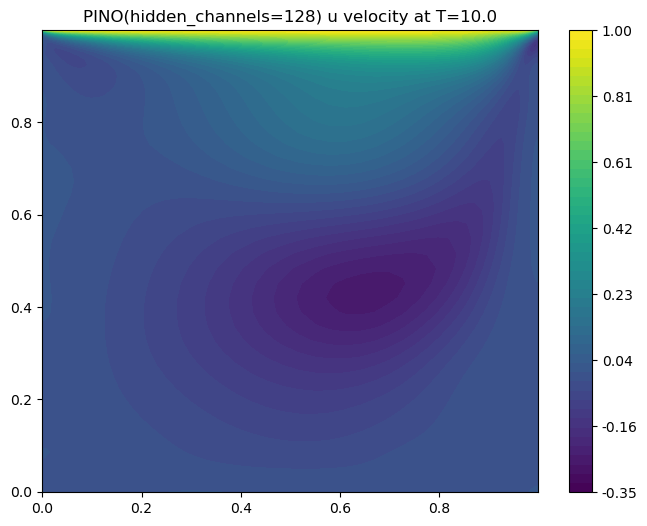

In [ ]:
# u velocity at the final time step (T=10.0)
plt.figure(figsize=(8, 6))

vmin, vmax = -0.35, 1.0
levels = np.linspace(vmin, vmax, 51)
ticks = np.linspace(vmin, vmax, 8)

u_plot = np.clip(pred[0, 0, :, :, -1], vmin, vmax)
cf = plt.contourf(
    X[:, :, 0], Y[:, :, 0], u_plot,
    levels=levels, vmin=vmin, vmax=vmax
  )
cbar = plt.colorbar(cf, ticks=ticks)
cbar.ax.set_yticklabels([f"{t:.2f}" for t in ticks])

plt.title('PINO(hidden_channels=128) u velocity at T=10.0')
plt.show()

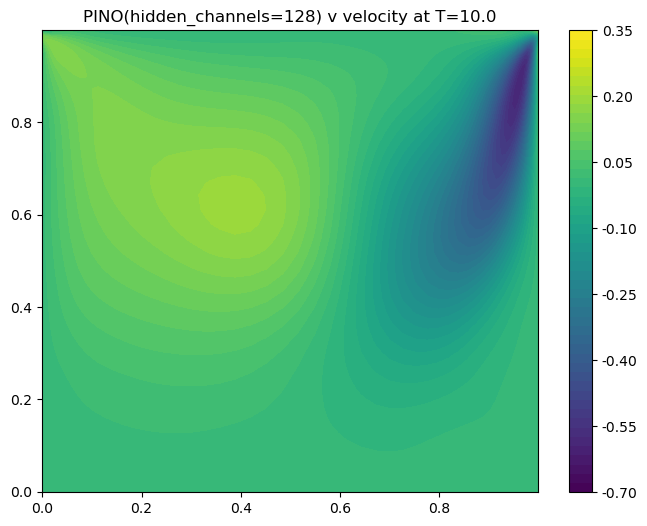

In [ ]:
# v velocity at the final time step (T=10.0)
plt.figure(figsize=(8, 6))

vmin, vmax = -0.7, 0.35
levels = np.linspace(vmin, vmax, 51)
ticks = np.linspace(vmin, vmax, 8)

v_plot = np.clip(pred[0, 1, :, :, -1], vmin, vmax)
cf = plt.contourf(
    X[:, :, 0], Y[:, :, 0], v_plot,
    levels=levels, vmin=vmin, vmax=vmax
  )
cbar = plt.colorbar(cf, ticks=ticks)
cbar.ax.set_yticklabels([f"{t:.2f}" for t in ticks])

plt.title('PINO(hidden_channels=128) v velocity at T=10.0')
plt.show()

In [ ]:
# quick smoke test (no training loop)
model.eval()
with torch.no_grad():
    pred_test = model(input_tensor_permuted.float())
    loss_test = lid_cavity_loss(
        pred_test,
        initial_condition=(u_tensor, v_tensor, p_tensor),
        dx=x_model,
        dy=y_model,
        dt=t,
    )
print(f"smoke test loss: {loss_test.item():.6f}")

smoke test loss: 2.533565


# 균일 격자

In [6]:
# 비균일 격자 좌표
x_nonuniform = x_model.numpy()
y_nonuniform = y_model.numpy()

# 균일 격자 생성
x_uniform = np.linspace(x_nonuniform[0], x_nonuniform[-1], cols)
y_uniform = np.linspace(y_nonuniform[0], y_nonuniform[-1], rows)
X_uni, Y_uni = np.meshgrid(x_uniform, y_uniform, indexing='ij')
pts = np.stack([X_uni.ravel(), Y_uni.ravel()], axis=-1)

# 비균일 -> 균일 보간
u_ref = RegularGridInterpolator((x_nonuniform, y_nonuniform), u_new.T, method='cubic')(pts).reshape(cols, rows)
v_ref = RegularGridInterpolator((x_nonuniform, y_nonuniform), v_new.T, method='cubic')(pts).reshape(cols, rows)
p_ref = RegularGridInterpolator((x_nonuniform, y_nonuniform), p_new.T, method='cubic')(pts).reshape(cols, rows)

u_ref_tensor = torch.from_numpy(u_ref).float().to(DEVICE)
v_ref_tensor = torch.from_numpy(v_ref).float().to(DEVICE)   
p_ref_tensor = torch.from_numpy(p_ref).float().to(DEVICE)
x_model_uni = torch.from_numpy(x_uniform).float().to(DEVICE)
y_model_uni = torch.from_numpy(y_uniform).float().to(DEVICE)

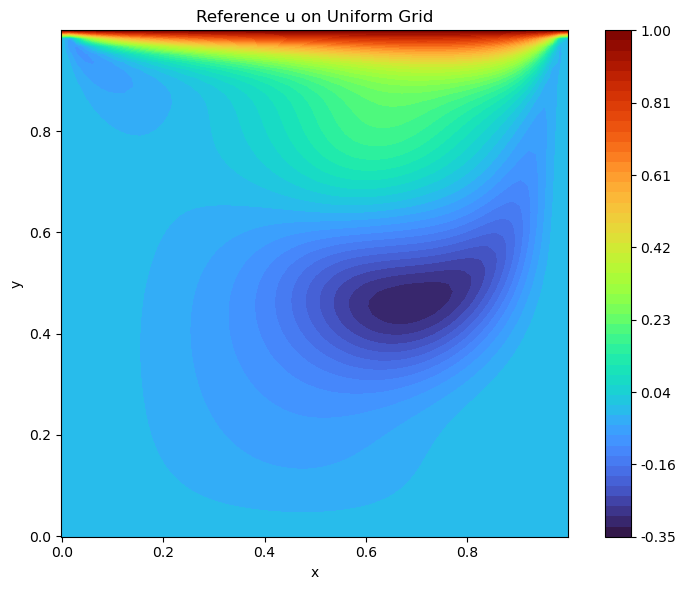

In [7]:
# u_ref 시각화 (균일 격자 기준)
plt.figure(figsize=(8, 6))

vmin, vmax = -0.35, 1.0
levels = np.linspace(vmin, vmax, 51)
ticks = np.linspace(vmin, vmax, 8)

cf = plt.contourf(X_uni, Y_uni, np.clip(u_ref, vmin, vmax), levels=levels, vmin=vmin, vmax=vmax, cmap='turbo')
cbar = plt.colorbar(cf, ticks=ticks)
cbar.ax.set_yticklabels([f"{tt:.2f}" for tt in ticks])

plt.title('Reference u on Uniform Grid')
plt.xlabel('x')
plt.ylabel('y')
plt.gca().set_aspect('equal')
plt.tight_layout()
plt.show()

In [8]:
hidden_channels = 64
model = FNO(
    n_modes = (8,8,8),
    in_channels=3,
    out_channels=3,
    hidden_channels=hidden_channels,
).to(DEVICE)

In [9]:
# creating the optimizer and scheduler
optimizer = torch.optim.Adam(model.parameters(), lr=2e-4)
scheduler = StepLR(optimizer, step_size=5000, gamma=0.5)

In [10]:
# uniform-grid input tensor for model
x_model_uni = x_model_uni.to(DEVICE)
y_model_uni = y_model_uni.to(DEVICE)
t_uni = t.to(DEVICE)

X_uni_t, Y_uni_t, T_uni_t = torch.meshgrid(x_model_uni, y_model_uni, t_uni, indexing='ij')
grid_tensor_uni = torch.stack([X_uni_t, Y_uni_t, T_uni_t], dim=-1)
input_tensor_uni = grid_tensor_uni.unsqueeze(0)
input_tensor_permuted_uni = input_tensor_uni.permute(0, 4, 1, 2, 3).contiguous()

print(f'uniform model grid shape: {grid_tensor_uni.shape}')
print(f'input_tensor_permuted_uni shape: {input_tensor_permuted_uni.shape}')

uniform model grid shape: torch.Size([65, 65, 51, 3])
input_tensor_permuted_uni shape: torch.Size([1, 3, 65, 65, 51])


In [11]:
num_iterations = 10000

model.train()
for step in range(num_iterations):
    optimizer.zero_grad()

    # 모델 예측
    pred = model(input_tensor_permuted_uni.float())

    # Loss 계산
    loss = lid_cavity_loss(
        pred,
        initial_condition=(u_ref_tensor, v_ref_tensor, p_ref_tensor),
        dx=x_model_uni,
        dy=y_model_uni,
        dt=t_uni,
    )

    # Backpropagation
    loss.backward()
    optimizer.step()
    scheduler.step()

    if (step + 1) % 100 == 0 or step == 0:
        print(f"Step {step+1}/{num_iterations}, Loss: {loss.item():.6f}")

os.makedirs('./model', exist_ok=True)
torch.save(model.state_dict(), f'./model/cavity_pino_hl{hidden_channels}uni.pth')

Step 1/10000, Loss: 2.321634
Step 100/10000, Loss: 0.153214
Step 200/10000, Loss: 0.088715
Step 300/10000, Loss: 0.073107
Step 400/10000, Loss: 0.063587
Step 500/10000, Loss: 0.056519
Step 600/10000, Loss: 0.049913
Step 700/10000, Loss: 0.045492
Step 800/10000, Loss: 0.041856
Step 900/10000, Loss: 0.039169
Step 1000/10000, Loss: 0.037391
Step 1100/10000, Loss: 0.036125
Step 1200/10000, Loss: 0.034920
Step 1300/10000, Loss: 0.034484
Step 1400/10000, Loss: 0.033007
Step 1500/10000, Loss: 0.033837
Step 1600/10000, Loss: 0.032100
Step 1700/10000, Loss: 0.031931
Step 1800/10000, Loss: 0.032313
Step 1900/10000, Loss: 0.030904
Step 2000/10000, Loss: 0.030600
Step 2100/10000, Loss: 0.031435
Step 2200/10000, Loss: 0.030333
Step 2300/10000, Loss: 0.029940
Step 2400/10000, Loss: 0.031387
Step 2500/10000, Loss: 0.029795
Step 2600/10000, Loss: 0.029472
Step 2700/10000, Loss: 0.029331
Step 2800/10000, Loss: 0.031049
Step 2900/10000, Loss: 0.029118
Step 3000/10000, Loss: 0.029005
Step 3100/10000, Los

In [13]:
X_uni.shape

(65, 65)

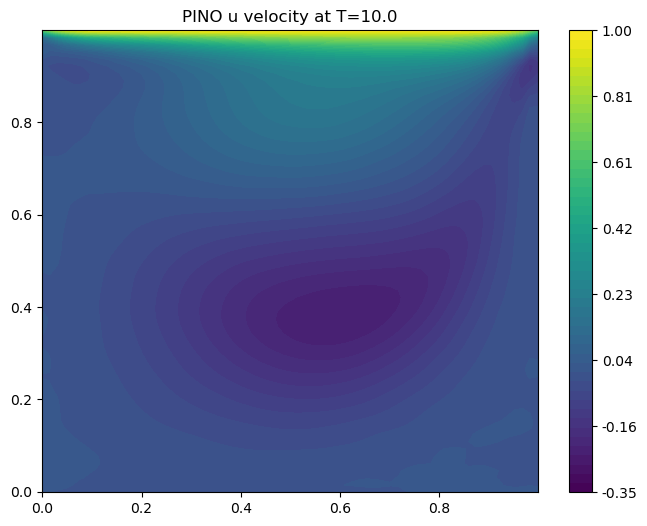

In [20]:
# u velocity at the final time step (T=10.0)
plt.figure(figsize=(8, 6))

vmin, vmax = -0.35, 1.0
levels = np.linspace(vmin, vmax, 51)
ticks = np.linspace(vmin, vmax, 8)

u_plot = np.clip(pred[0, 0, :, :, -1].cpu().detach().numpy(), vmin, vmax)
cf = plt.contourf(
    X_uni, Y_uni, u_plot,
    levels=levels, vmin=vmin, vmax=vmax
  )
cbar = plt.colorbar(cf, ticks=ticks)
cbar.ax.set_yticklabels([f"{t:.2f}" for t in ticks])

plt.title('PINO u velocity at T=10.0')
plt.show()

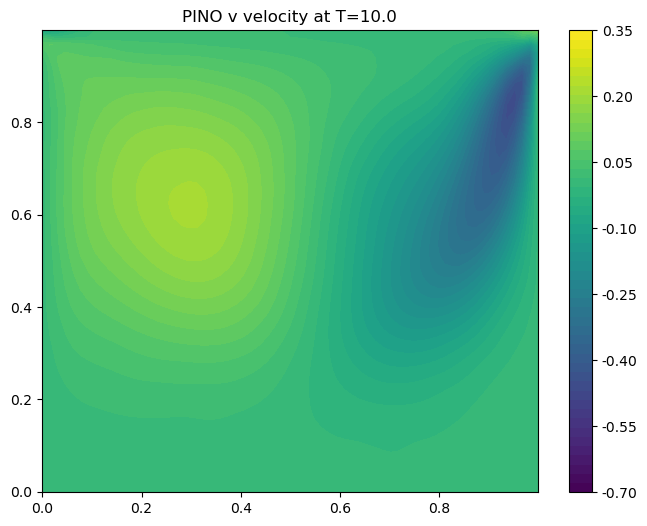

In [21]:
# v velocity at the final time step (T=10.0)
plt.figure(figsize=(8, 6))

vmin, vmax = -0.7, 0.35
levels = np.linspace(vmin, vmax, 51)
ticks = np.linspace(vmin, vmax, 8)

v_plot = np.clip(pred[0, 1, :, :, -1].cpu().detach().numpy(), vmin, vmax)
cf = plt.contourf(
    X_uni, Y_uni, v_plot,
    levels=levels, vmin=vmin, vmax=vmax
  )
cbar = plt.colorbar(cf, ticks=ticks)
cbar.ax.set_yticklabels([f"{t:.2f}" for t in ticks])

plt.title('PINO v velocity at T=10.0')
plt.show()

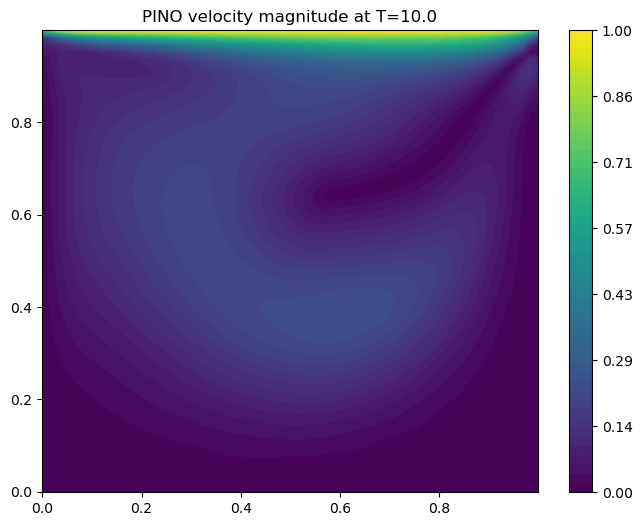

In [19]:
# v velocity at the final time step (T=10.0)
plt.figure(figsize=(8, 6))

vmin, vmax = 0, 1
levels = np.linspace(vmin, vmax, 51)
ticks = np.linspace(vmin, vmax, 8)

v_plot = np.clip(pred[0, 1, :, :, -1].cpu().detach().numpy(), vmin, vmax)
cf = plt.contourf(
    X_uni, Y_uni, np.sqrt(v_plot**2 + u_plot**2),
    levels=levels, vmin=vmin, vmax=vmax
  )
cbar = plt.colorbar(cf, ticks=ticks)
cbar.ax.set_yticklabels([f"{t:.2f}" for t in ticks])

plt.title('PINO velocity magnitude at T=10.0')
plt.show()